In [1]:
using PeriodicOrbitTTV
using NbodyGradient
using PyCall
using PyPlot
using Rotations
using Statistics

First, I reran the original GM20 script and then extracted cartesian pos/vel.

The cell below is the values I got from the rebound. I copied the parameters directly from `rebound`. My only modification is that I set the star mass to 1.0 instead of 1.52 (and planet masses accordingly) so we don't have to scale sma or period.

In [2]:
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = true

true

In [3]:
# Initial positions provided by Gozdziewski
init_carts = vcat([ 1.00000000e+00  4.61496489e-03  5.63490167e-03  4.89322595e-03 3.67651758e-03],
 [-1.36928916e-01  2.51486075e+00 -5.08846256e+00 -2.10399825e+01 6.98893154e+01],
 [ 1.45996008e-02  1.39051628e+01  2.49296772e+01 -3.76679792e+01 -9.50078029e+00],
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00 0.00000000e+00],
 [ 2.96442444e-05 -4.80417369e-03 -3.45488516e-03  2.23875914e-03 2.82885176e-04],
 [-1.98056552e-06  5.85355751e-04 -3.21201559e-04 -1.31277180e-03 2.04345481e-03],
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00 0.00000000e+00],)

7×5 Matrix{Float64}:
  1.0          0.00461496    0.0056349      0.00489323   0.00367652
 -0.136929     2.51486      -5.08846      -21.04        69.8893
  0.0145996   13.9052       24.9297       -37.668       -9.50078
  0.0          0.0           0.0            0.0          0.0
  2.96442e-5  -0.00480417   -0.00345489     0.00223876   0.000282885
 -1.98057e-6   0.000585356  -0.000321202   -0.00131277   0.00204345
  0.0          0.0           0.0            0.0          0.0

Then, I converted this matrix into OptimParameters (since we don't natively support cartesian optimization at this time)

In [4]:
ic_rb = CartesianIC(0., 4+1, permutedims(init_carts))
s_rb = State(ic_rb)

using PeriodicOrbitTTV: extract_elements

orbparams = OrbitParameters(4, [0.5, 0.5], 5000.)

optvec_0 = extract_elements(s_rb.x, s_rb.v, s_rb.m, orbparams)

20-element Vector{Float64}:
     0.1442180304531095
     0.11377308738187768
     0.052735122494783626
     0.015875975652979137
     5.866226729482573
     1.060327574446483
     2.5295603587642903
     5.450138713262406
    -1.443361731434318
     1.123976909027346
    -0.8971145684652007
    -0.28969377049503553
    -0.2982989616775713
 23782.055078432564
     0.00461496489
     0.00563490167
     0.00489322595
     0.00367651758
     2.100552470797788
     1.9383014898156965

In [5]:
# Objective functions and derivatives
function residues(optvec::Vector{T}, truthvec::Vector{T}, weights_periodic::Vector{T}, nplanet::Int, orbparams::OrbitParameters{T}, tt_data::Matrix{T}, scaler::Vector{T}) where T <: Real
    residues = zeros(T, 9nplanet - 1 + size(tt_data, 1))
    optvec = optvec .* scaler
    
    # PO Contribution
    orbit = Orbit(nplanet, OptimParameters(nplanet, optvec), orbparams)
    residues[1:4nplanet-2] = (param_diff(3, orbit.final_elem, orbit.init_elem)[1:end-2]) ./ scaler[1:4nplanet-2]

    # Prior contribution
    residues[4nplanet-1:9nplanet-1] .= 0
    
    # TT Contribution
    tt = compute_tt(orbit, orbparams.obstmax)
    tmod, ip, jp = match_transits(tt_data, orbit, tt.tt, tt.count, nothing)
    # tt_mat = to_matrix(tt.tt)
    residues[9nplanet:end] = tmod
    
    return residues
end

function llhood_jac(_, θ)
    transformed = θ .* scaler
        
    optparams = OptimParameters(nplanet, transformed)
    
    jac = compute_diff_squared_jacobian(optparams, orbparams, nplanet, tt_data)
    jac[1:4nplanet-2,:] .= jac[1:4nplanet-2,:] ./ scaler[1:4nplanet-2]
    
    return jac .* scaler'
end


llhood_jac (generic function with 1 method)

In [6]:
# Modify P1
P1 = 23782.055078432564
optvec_0[end-6] = P1
optvec_0 = vcat(optvec_0, 7.8*P1)

println("Initial: $optvec_0")
println()

lower_bounds = vcat(
    [0., 0., 0.,0.],
    [-2pi, -2pi, -2pi, -2pi],
    [-2pi, -2pi, -2pi],
    [-1., -1.],
    [0.5*P1],
    [1e-8, 1e-8, 1e-8, 1e-8],
    [1.8],
    [-2pi],
    [0*P1],
)

upper_bounds = vcat(
    [0.4, 0.4, 0.4, 0.4],
    [2pi, 2pi, 2pi, 2pi],
    [2pi, 2pi, 2pi],
    [1., 1.],
    [2.0*P1],
    [1e-2, 1e-2, 1e-2, 1e-2],
    [2.4],
    [2pi],
    [16*P1],
)

prior_weights = vcat(
    [0., 0., 0., 0.],
    [0., 0., 0., 0.],
    [0., 0., 0.],
    [0., 0.],
    [1e8],
    [1e8, 1e8, 1e8, 1e8],
    [1e8],
    [1e8],
    [0.],
)

optparams_0 = OptimParameters(4, optvec_0)

optres, scale_factor = find_periodic_orbit(optparams_0, orbparams, maxit=1000, 
    lower_bounds=lower_bounds, upper_bounds=upper_bounds, prior_weights=prior_weights);

println("Final: $(optres.param) .* scale_factor")

Initial: [0.1442180304531095, 0.11377308738187768, 0.052735122494783626, 0.015875975652979137, 5.866226729482573, 1.060327574446483, 2.5295603587642903, 5.450138713262406, -1.443361731434318, 1.123976909027346, -0.8971145684652007, -0.28969377049503553, -0.2982989616775713, 23782.055078432564, 0.00461496489, 0.00563490167, 0.00489322595, 0.00367651758, 2.100552470797788, 1.9383014898156965, 185500.029611774]

Final: [140.372513798947, 107.90096333580314, 50.13790557416151, 16.11324934073474, 5.883427818924225, 1.0681713246733315, 2.5035619553462833, 5.450981415105924, -1.4341090381702455, 1.1481492235064619, -0.8993343703883405, -284.75703494241816, -290.1397995504919, 23.782055078432563, 461.496489, 563.490167, 489.322595, 367.651758, 2.100552470797788, 1.9383014898156965, 18.571928165708524] .* scale_factor


In [7]:
# Rescale and create orbit object for further analysis
optres_vec = optres.param .* scale_factor

optparams_1 = OptimParameters(orbparams.nplanet, optres_vec)
orbit_1 = Orbit(orbparams.nplanet, optparams_1, orbparams)

Orbit
Number of planets: 4
Current time: 0.0
Planet masses: [0.00461496489, 0.005634901670000001, 0.00489322595, 0.00367651758]


In [8]:
# Rotation

function diff_angle_jac(init_state, final_state, ic)
    shifting_angle = get_Jacobi_orbital_elements(final_state, ic)[2].ω - get_Jacobi_orbital_elements(init_state, ic)[2].ω
    shifting_angle = rem2pi(shifting_angle, RoundNearest)
    return shifting_angle
end

function diff_pos(init_state, final_state, ic)
    shifting_angle = get_orbital_elements(final_state, ic)[2].ω - get_orbital_elements(init_state, ic)[2].ω
    shifting_angle = rem2pi(shifting_angle, RoundNearest)
    println("Shifting angle: $shifting_angle")

    init_pos = init_state.x
    final_pos = final_state.x
    
    rot_matrix = RotXYZ(0, 0, -shifting_angle)
    pos_diff = (rot_matrix * final_pos) - init_pos
    return pos_diff
end

function diff_vel(init_state, final_state, ic)
    shifting_angle = get_orbital_elements(final_state, ic)[2].ω - get_orbital_elements(init_state, ic)[2].ω
    shifting_angle = rem2pi(shifting_angle, RoundNearest)
    println("Shifting angle: $shifting_angle")

    init_vel = init_state.v
    final_vel = final_state.v
    
    rot_matrix = RotXYZ(0, 0, -shifting_angle)
    vel_diff = (rot_matrix * final_vel) - init_vel
    return vel_diff
end

diff_vel (generic function with 1 method)

In [9]:
# Long-term stability plot

function figure_A7_plot(state, ic, intstep, timestep, timemax)
    arb_state = deepcopy(state)
    
    @show h = intstep
    @show n_steps = convert(Int, timemax ÷ timestep)
    
    e_1 = Vector{Any}(undef, n_steps)
    e_2 = Vector{Any}(undef, n_steps)
    e_3 = Vector{Any}(undef, n_steps)
    e_4 = Vector{Any}(undef, n_steps)
    
    lambda_1 = Vector{Any}(undef, n_steps)
    lambda_2 = Vector{Any}(undef, n_steps)
    lambda_3 = Vector{Any}(undef, n_steps)
    lambda_4 = Vector{Any}(undef, n_steps)
    
    P1 = Vector{Any}(undef, n_steps)
    P2 = Vector{Any}(undef, n_steps)
    P3 = Vector{Any}(undef, n_steps)
    P4 = Vector{Any}(undef, n_steps)

    ω1 = Vector{Any}(undef, n_steps)
    ω2 = Vector{Any}(undef, n_steps)
    ω3 = Vector{Any}(undef, n_steps)
    ω4 = Vector{Any}(undef, n_steps)
    
    times = Vector{Any}(undef, n_steps)
    
    for i = 1:n_steps
        Integrator(ahl21!,h,timestep)(arb_state)
        
        times[i] = arb_state.t[1]/(365.242*1e3)
    
        e_1[i] = get_Jacobi_orbital_elements(arb_state, ic)[2].e
        e_2[i] = get_Jacobi_orbital_elements(arb_state, ic)[3].e
        e_3[i] = get_Jacobi_orbital_elements(arb_state, ic)[4].e
        e_4[i] = get_Jacobi_orbital_elements(arb_state, ic)[5].e
    
        lambda_1[i] = get_Jacobi_anomalies(arb_state, ic)[1][1] + get_Jacobi_orbital_elements(arb_state, ic)[2].ω
        lambda_2[i] = get_Jacobi_anomalies(arb_state, ic)[2][1] + get_Jacobi_orbital_elements(arb_state, ic)[3].ω
        lambda_3[i] = get_Jacobi_anomalies(arb_state, ic)[3][1] + get_Jacobi_orbital_elements(arb_state, ic)[4].ω
        lambda_4[i] = get_Jacobi_anomalies(arb_state, ic)[4][1] + get_Jacobi_orbital_elements(arb_state, ic)[5].ω
    
        P1[i] = get_Jacobi_orbital_elements(arb_state, ic)[2].P
        P2[i] = get_Jacobi_orbital_elements(arb_state, ic)[3].P
        P3[i] = get_Jacobi_orbital_elements(arb_state, ic)[4].P
        P4[i] = get_Jacobi_orbital_elements(arb_state, ic)[5].P

        ω1[i] = get_Jacobi_orbital_elements(arb_state, ic)[2].ω
        ω2[i] = get_Jacobi_orbital_elements(arb_state, ic)[3].ω
        ω3[i] = get_Jacobi_orbital_elements(arb_state, ic)[4].ω
        ω4[i] = get_Jacobi_orbital_elements(arb_state, ic)[5].ω
    end

    return times, e_1, e_2, e_3, e_4, lambda_1, lambda_2, lambda_3, lambda_4, P1, P2, P3, P4, ω1, ω2, ω3, ω4
end
    

figure_A7_plot (generic function with 1 method)

In [10]:
# Difference in positions (AU)
diff_pos(orbit_1.s, orbit_1.state_final, orbit_1.ic)

Shifting angle: -0.9188339773281673


3×5 Matrix{Float64}:
 -2.11886e-13  -3.39639e-12  1.67235e-11   4.6132e-11   -2.52101e-11
  5.41641e-14   1.1692e-11   6.62936e-12  -7.77405e-11   6.39959e-11
  0.0           0.0          0.0           0.0           0.0

In [11]:
# Difference in velocities (AU/days)
diff_vel(orbit_1.s, orbit_1.state_final, orbit_1.ic)

Shifting angle: -0.9188339773281673


3×5 Matrix{Float64}:
 -8.60924e-18   3.30899e-15  4.0289e-16   -4.46258e-16  -1.83602e-15
 -2.41919e-17  -4.17255e-16  6.60333e-16   4.08571e-15   6.54858e-16
  0.0           0.0          0.0           0.0           0.0

In [12]:
# Summary
# Various quantities at t = 0

# Semi-major axis
for i = 1:4
    println("a$i: $(get_orbital_elements(orbit_1.s, orbit_1.ic)[i+1].a)")
end
println()

# Eccentricities
for i = 1:4
    println("ecc$i: $(get_orbital_elements(orbit_1.s, orbit_1.ic)[i+1].e)")
end
println()

# Longitude of periastron
for i = 1:4
    ωi = rad2deg(rem2pi(get_orbital_elements(orbit_1.s, orbit_1.ic)[i+1].ω, RoundNearest))
    println("ω$i: $(ωi)")
end
println()

# Mean anomalies
for i = 1:4
    Mi = rad2deg(rem2pi(get_anomalies(orbit_1.s, orbit_1.ic)[i][2], RoundNearest))
    println("M$i: $(Mi)")
end
println()

# Rotation angle
Δϕ = rem2pi(get_orbital_elements(orbit_1.state_final, orbit_1.ic)[2].ω 
    - get_orbital_elements(orbit_1.s, orbit_1.ic)[2].ω, RoundNearest)
println("Δϕ: $(Δϕ)")

a1: 16.210682331754583
a2: 26.597279458669238
a3: 41.345056205468055
a4: 71.71470501331223

ecc1: 0.14037251379894722
ecc2: 0.10790096333580239
ecc3: 0.050137905574160174
ecc4: 0.01611324934071886

ω1: 111.0564947903592
ω2: 28.888099541637878
ω3: 94.67220429978076
ω4: 43.14414050547404

M1: -22.904416905783062
M2: 61.20170870068052
M3: 143.44353379086573
M4: -47.68177071013377

Δϕ: -0.9188339773281673


In [13]:
# Plot with a finer plot timestep (would it help with the straight line segments?)

h = intstep = 237.82055078432563
n_steps = convert(Int, timemax ÷ timestep) = 36524


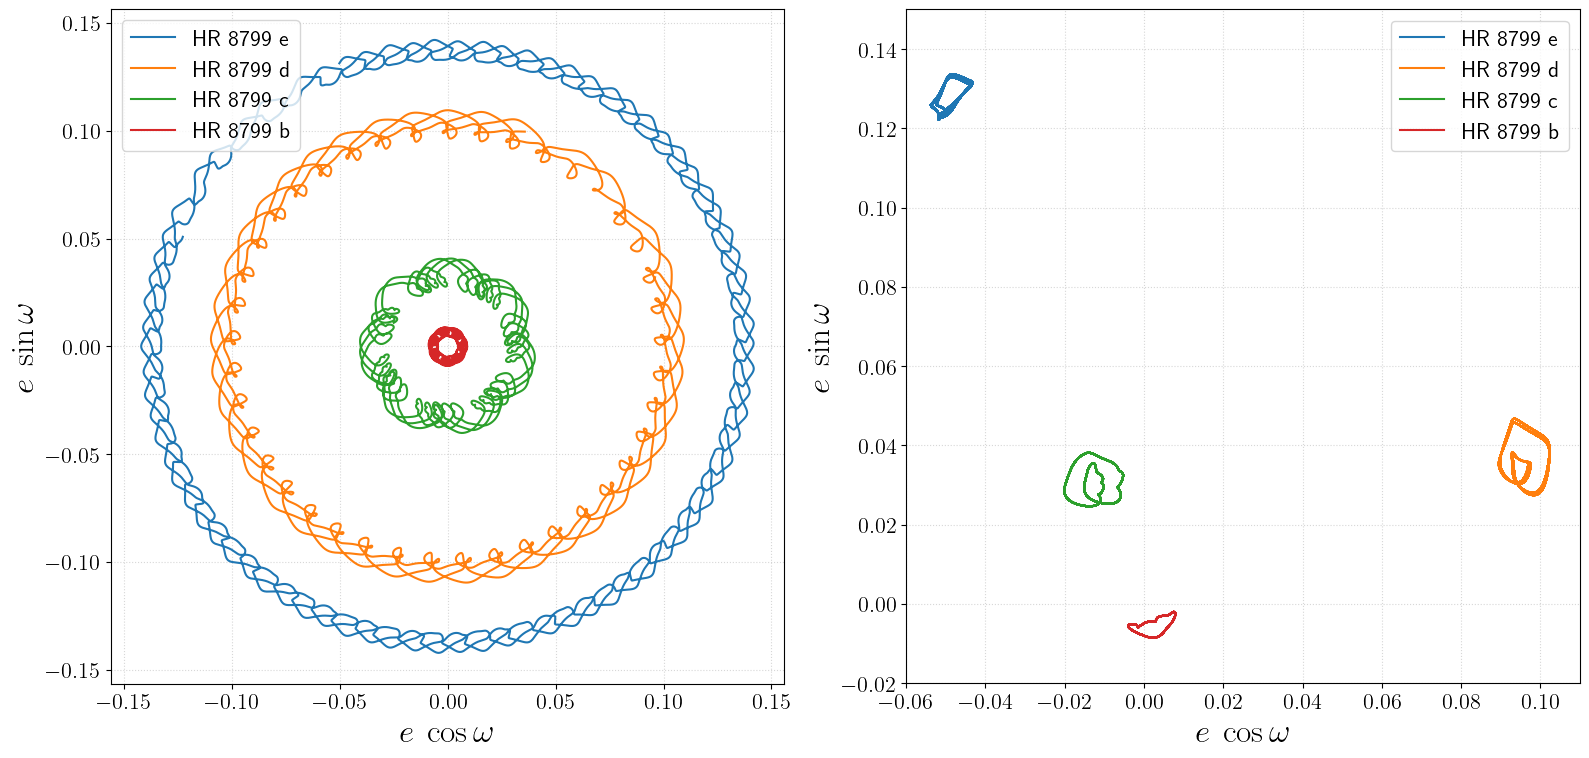

In [14]:
times, e_1, e_2, e_3, e_4, lambda_1, lambda_2, lambda_3, lambda_4, P1, P2, P3, P4, ω1, ω2, ω3, ω4 = 
    # figure_A7_plot(orbit_1.s, orbit_1.ic, optparams_1.inner_period / 100, optparams_1.tsys/30.0, 10*365.242*1e3);
    figure_A7_plot(orbit_1.s, orbit_1.ic, optparams_1.inner_period / 100, 100., 10*365.242*1e3);

shifted_omega = diff_angle_jac(orbit_1.s, orbit_1.state_final, orbit_1.ic)
t_sys = optres_vec[end] / (365.242*1e3) # ka

ω1_rot = ω1 .- (shifted_omega / t_sys) .* times
ω2_rot = ω2 .- (shifted_omega / t_sys) .* times
ω3_rot = ω3 .- (shifted_omega / t_sys) .* times
ω4_rot = ω4 .- (shifted_omega / t_sys) .* times 

fig, ax = subplots(1, 2, figsize=(16,8), tight_layout=true)

# ax[1].set_title("Inertial Frame", fontsize=26)
ax[1].plot(e_1.*cos.(ω1), e_1.*sin.(ω1),label="HR 8799 e")
ax[1].plot(e_2.*cos.(ω2), e_2.*sin.(ω2),label="HR 8799 d")
ax[1].plot(e_3.*cos.(ω3), e_3.*sin.(ω3),label="HR 8799 c")
ax[1].plot(e_4.*cos.(ω4), e_4.*sin.(ω4),label="HR 8799 b")

# ax[2].set_title("Rotating Frame", fontsize=26)
ax[2].plot(e_1.*cos.(ω1_rot), e_1.*sin.(ω1_rot),label="HR 8799 e")
ax[2].plot(e_2.*cos.(ω2_rot), e_2.*sin.(ω2_rot),label="HR 8799 d")
ax[2].plot(e_3.*cos.(ω3_rot), e_3.*sin.(ω3_rot),label="HR 8799 c")
ax[2].plot(e_4.*cos.(ω4_rot), e_4.*sin.(ω4_rot),label="HR 8799 b")

for i in 1:2
    ax[i].set_xlabel("\$e\\:\\cos{\\omega}\$", fontsize=24)
    ax[i].set_ylabel("\$e\\:\\sin{\\omega}\$", fontsize=24)
    ax[i].grid(linestyle=":", alpha=0.5)
    ax[i].set_aspect("equal")
    ax[i].legend(fontsize=16)

    ax[i].tick_params("both", labelsize=16)
end

ax[2].set_xlim(-0.06, 0.11)
ax[2].set_ylim(-0.02, 0.15)

savefig("figures/gm20_10aka_vector_dual.pdf")